In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys

import pandas as pd
    
sys.path.insert(1, "../../")

import precision_mapping as pm
# import voxel_analysis as pm
import CAP_tools


sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

ModuleNotFoundError: No module named 'torch_math_tools'

# Tests

## Argument Defs

In [2]:
overwrite = False
n_ciftis = 10

exclude_subcortex = True
mask = False
sparsity = 0.1
max_trs = 100

prefix = "example"
out_dir = "../tests/outputs"

cifti_path = "../tests/inputs/example.dtseries.nii"

In [3]:
label_tag = pm.utils.create_path_tag(prefix, sparsity, mask, exclude_subcortex, max_trs=max_trs)
print(label_tag)

save_path = f"{out_dir}/{label_tag}.npz"
save_path_i = f"{out_dir}/{label_tag}_{{i}}.npz"

cifti_paths = [cifti_path] * n_ciftis
save_paths = [save_path_i.format(i=i) for i in range(n_ciftis)]

example_S1_TR100


## Test parallel / batch Sparse Dconn Creation

In [13]:
pm.utils.printer.silent = True

In [14]:
pm.functional_connectivity.generate_correlation_matrix(cifti_path, save_path, max_trs=max_trs, overwrite=overwrite)

'../tests/outputs/example_S1_TR100.npz'

In [15]:
matrix_paths = pm.functional_connectivity.generate_correlation_matrix(cifti_paths, save_paths, max_trs=max_trs, overwrite=overwrite)

  0%|          | 0/10 [00:00<?, ?it/s]

## Test parallel infomaps

In [71]:
parcel_save_paths = [p.replace(".npz", ".npy") for p in matrix_paths]

In [72]:
pm.parcellate.parcel_detection(matrix_paths, parcel_save_paths, n_cores=3, n_reps=1, overwrite=overwrite)

KeyboardInterrupt: 

# Real Data

### Parameters

In [2]:
overwrite = False
n_ciftis = 10

exclude_subcortex = True
mask = False
sparsity = 0.1
max_trs = 300

silent = True


pm.utils.printer.silent = silent

### paths

In [9]:
ls ~/

Applications/
Desktop/
Documents/
Downloads/
Google Drive@
Library/
Movies/
Music/
NC_results@
OneDrive - New York State Office of Information Technology Services@
Pictures/
Public/
Zotero/
_tmp/
local/
matlab/
miniconda3/
neuromaps-data/
notebooks/
raid@


In [1]:
results_dir = "/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL"
dtseries_list_txt = "/data/data7/network_control/scripts/_params/HCP_7T_CAP_analysis/HCP_7T_CAP_analysis_rfMRI_REST_7T_ALL_dtseries_list.txt"

with open(dtseries_list_txt) as file:
    dtseries_paths = file.read().strip().split()

cached_dtseries_paths = pm.utils.cache_tmp_path(dtseries_paths, write_cache=True)

subjects = [path.split("/MNINon")[0].split("/")[-1] for path in dtseries_paths]

voxel_FC_file_ending = "voxel_FC.npz"
parcel_file_ending = "parcellation.npy"
network_file_ending = "networks.npy"

NameError: name 'pm' is not defined

##### Sparse dconn creation

In [5]:
import gc
import torch

# TODO: Fix correlation matrix functions :(

In [6]:
# for max_trs in [300, 600, 1200, 2400]:
# for max_trs in [None, 300, 1200, 2400]:
for max_trs in [300, 1200, 2400, None]:
    generic_save_paths = []
    for subject in subjects:
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
    
    
    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]
    
    _ = pm.functional_connectivity.generate_correlation_matrix(cached_dtseries_paths, voxel_FC_save_paths,
                                                               max_trs=max_trs, overwrite=overwrite)
    torch.mps.empty_cache()
    gc.collect()
    pm.parcellate.parcel_detection(voxel_FC_save_paths, parcel_save_paths, n_cores=10, n_reps=1, overwrite=overwrite)
    gc.collect()
    pm.na.assign_networks_batch(cached_dtseries_paths, parcel_save_paths, network_save_paths)

Generating vertex-level FC:   0%|          | 0/177 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

Generating vertex-level FC:   0%|          | 0/177 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

...

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

Generating vertex-level FC:   0%|          | 0/177 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

## Network Assignments

In [7]:
# pm.parcellate.parcel_detection(matrix_paths, parcel_save_paths, n_cores=10, n_reps=1, overwrite=overwrite)

In [467]:
pm.na.assign_networks_batch(cached_dtseries_paths, parcel_save_paths, network_save_paths);

  0%|          | 0/177 [00:00<?, ?it/s]

# Assignment FC Analysis

In [9]:
sc_path = voxel_FC_save_paths[0]
print(sc_path)
print(dtseries_paths[0])
print(parcel_save_paths[0])
print(network_save_paths[1])

/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/100610/100610_S1_voxel_FC.npz
/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/rfMRI_REST_7T_ALL/rfMRI_REST_7T_ALL_Atlas_hp2000_clean_nilearn.dtseries.nii
/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/100610/100610_S1_parcellation.npy
/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_networks.npy


In [10]:
import scipy
import numpy as np
import nibabel as nb

import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
import glob

In [12]:
vfc_paths = glob.glob("/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311*_voxel_FC.npz")
for vfc_path in vfc_paths:
    print(vfc_path)
    vfc_i = scipy.sparse.load_npz(vfc_path)
    print(vfc_i.data.shape, np.max(vfc_i), np.mean(vfc_i), np.min(vfc_i))
    print(vfc_i.__repr__())
    # break

/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_voxel_FC.npz
(8332312,) 2.99506 0.0004273211 0.0
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7284834 stored elements and shape (91282, 91282)>
/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_TR300_voxel_FC.npz
(8332312,) 2.9956744 0.00047845452 0.0
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7523222 stored elements and shape (91282, 91282)>
/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_TR1200_voxel_FC.npz
(8332312,) 2.994267 0.00044855816 0.0
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7428334 stored elements and shape (91282, 91282)>
/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_TR2400_voxel_FC.npz
(8332312,) 2.9951873 0.00043804618 0.0
<Compressed Sparse Row sparse matrix of dtyp

# Size Stability Metrics

In [544]:
example_cifti = nb.load(cached_dtseries_paths[0])

In [545]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), example_cifti)
medial_wall_mask_L = np.isnan(medial_wall_mask_values["left"])
medial_wall_mask_R = np.isnan(medial_wall_mask_values["right"])
medial_wall_mask_64k = np.hstack([medial_wall_mask_L, medial_wall_mask_R])

Text(0.5, 1.0, 'Mean Vertex Surface Area')

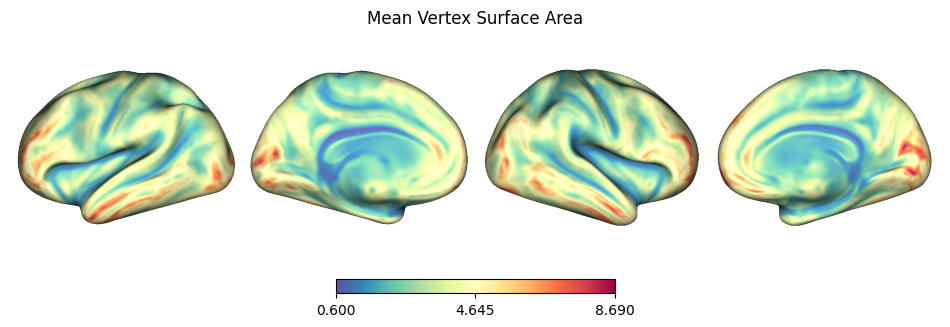

In [560]:
generic_area_file = "/data/data4/earlycort_7114/*/MNINonLinear/fsaverage_LR32k/*.{side}.midthickness.32k_fs_LR.area.func.gii"

all_L_area_files = glob.glob(generic_area_file.format(side="L"))
all_R_area_files = glob.glob(generic_area_file.format(side="R"))

L_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_L_area_files]), -1)
R_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_R_area_files]), -1)
SA_all_64k = np.concat([L_SA_all_32k, R_SA_all_32k], axis=1)
SA_all_cortex = SA_all_64k[:, ~medial_wall_mask_64k]
mean_SA_cortex = np.mean(SA_all_cortex, axis=0)

mean_L_SA = np.mean(L_SA_all_32k, axis=0)[:, 0]
mean_R_SA = np.mean(R_SA_all_32k, axis=0)[:, 0]

mean_SA_values = {"left": mean_L_SA, "right": mean_R_SA}
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(mean_SA_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title("Mean Vertex Surface Area")

In [500]:
vni_s, vns_s = [], []
tr_label_s = []
for max_trs in [300, 1200, 2400, None]:
    generic_save_paths = []
    for subject in subjects:
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
    
    
    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]
    
    for network_path in tqdm(network_save_paths):
        vni, vns = np.load(network_path)
        vns_s.append(vns)
        vni_s.append(vni)
        tr_label_s.append(max_trs)

vns_s = np.array(vns_s)
vni_s = np.array(vni_s).astype(int)
tr_label_s = np.array(tr_label_s)
tr_label_s = np.array([i if i else 3600 for i in tr_label_s])

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

In [561]:
vert_counts = np.array([(vns_s == net).mean(axis=1) for net in tqdm(network_labels, leave=False)]).T

  0%|          | 0/21 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [588]:
compare_table = np.arange(np.max(vni_s) + 2).reshape(1, 1, -1)
ni_index_set = np.expand_dims(vni_s, 2) == compare_table
sizes = mean_SA_cortex * ni_index_set
size_frac = sizes / sizes.sum(axis=(1, 2), keepdims=True)
network_sizes = size_frac.sum(axis=1)

In [708]:
EC_vert_size_csv = "/data/data7/network_control/projects/voxel_analysis/notebooks/scratch/EC_vert_count_data.csv"
EC_df = pd.read_csv(EC_vert_size_csv)
szp_index = EC_df["subject"].str.contains("_08_").values
EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

# EC_sizes_csv = "/data/data7/network_control/projects/voxel_analysis/notebooks/scratch/EC_sizes_data.csv"
# EC_df = pd.read_csv(EC_sizes_csv)
# szp_index = EC_df["subject"].str.contains("_08_").values
# EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

In [709]:
df = pd.DataFrame(vert_counts, columns=network_labels)
# df = pd.DataFrame(network_sizes, columns=network_labels)
df["subject"] = np.tile(subjects, (len(np.unique(tr_label_s))))
df["TR"] = tr_label_s

df = pd.concat([df, EC_df])
mdf = pd.melt(df, id_vars=["subject", "TR"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

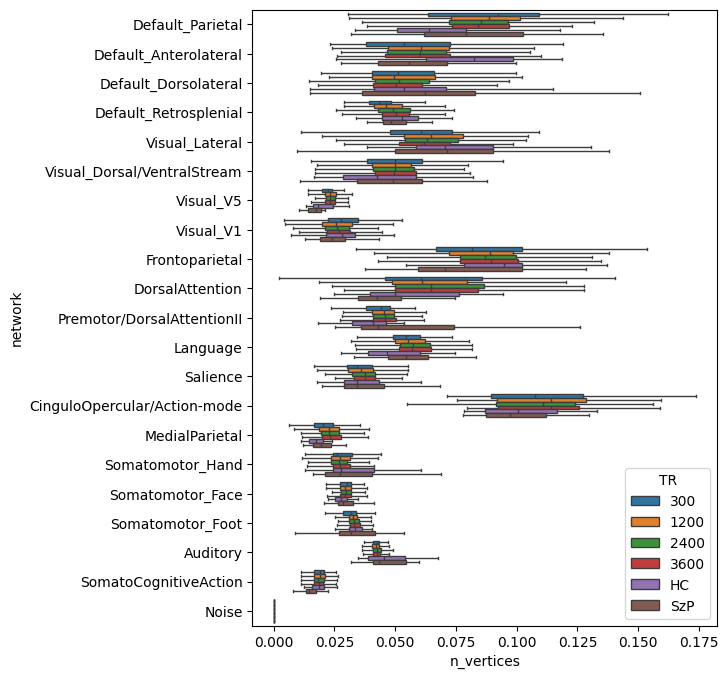

In [710]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)
# sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)

In [718]:
hcp_1200 = df.query("TR == 1200")
szp_df = df.query("TR == 'SzP'")
hc_df = df.query("TR == 'HC'")

hcp_df = df.loc[df["TR"].apply(lambda s: isinstance(s, int))]

In [719]:
t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])

for n, t, p in zip(network_labels, t_s, p_s):
    if p < 0.05:
        print(f"{n}:: {t:0.2f} {p:0.5f}")

Default_Parietal:: 2.73 0.00692
Default_Anterolateral:: -3.94 0.00011
Default_Retrosplenial:: -2.35 0.01975
Language:: 3.01 0.00296
MedialParietal:: 3.25 0.00135
Somatomotor_Hand:: -2.40 0.01736
Somatomotor_Foot:: -2.06 0.04035
Auditory:: -5.38 0.00000


In [713]:
mtr_df = pd.melt(df[network_labels].groupby(df["TR"]).std().reset_index(), id_vars=["TR"], var_name="network", value_name="std")

In [714]:
size_corrs = []
for subject, subj_df in hcp_df.groupby("subject"):
    z = subj_df.sort_values("TR").drop("subject", axis=1).set_index("TR").T.corr()[3600]
    trs = z.index.values
    size_corrs.append(z.values)
size_corrs = np.array(size_corrs) ** 2
trs = trs.astype(int)

[Text(0.5, 0, 'Resting State Duration (Minutes)'),
 Text(0, 0.5, 'Size Correlation (R^2)')]

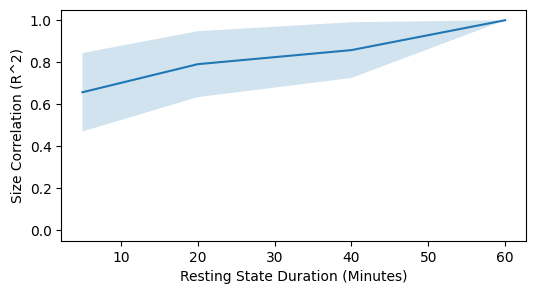

In [715]:
t = trs / 60
m, std = np.mean(size_corrs, axis=0),  np.std(size_corrs, axis=0)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, m)
ax.fill_between(t, m - std, m + std, alpha=0.2)
ax.set_ylim(-0.05, 1.05)
ax.set(xlabel="Resting State Duration (Minutes)", ylabel="Size Correlation (R^2)")

<Axes: xlabel='std', ylabel='network'>

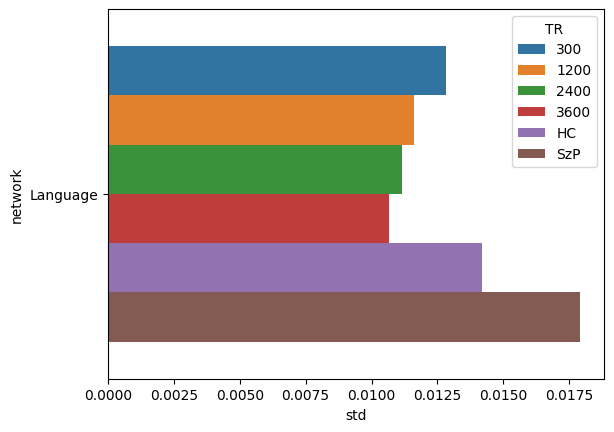

In [628]:
sns.barplot(data=mtr_df.query("network == 'Language'"), y="network", hue="TR", x="std")

# Intra Parcel Connectivity Analysis

In [126]:
ex_index = 0

In [327]:
network_path = network_save_paths[ex_index]
FC_path = voxel_FC_save_paths[ex_index]
partition_path = parcel_save_paths[ex_index]

template_cifti = template_cifti

In [446]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def load_partition_labels(partition_path, template_cifti):
    """ """
    partition = np.load(partition_path)
    vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
    vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
    remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
    return remapped_vertex_labels

def load_network_labels(network_path):
    return np.load(network_save_path)[0].astype(int)

def safe_mean(arr, **kwargs):
    # if arr.ndim == 1 and len(arr) == 0:
    #     return np.nan
    return np.mean(arr, **kwargs)


def calculate_mean_ROI_fc(sc_cortex, vertex_labels, only_nonzero=True, partial_nonzero=True):
    """ """
    unl = np.sort(np.unique(vertex_labels))
    if only_nonzero:
        mean_parcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label].data) for label in unl])
        mean_intraparcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label][:, vertex_labels == label].data) for label in unl])
    elif partial_nonzero:
        parcel_fc_z = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_z])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[(parcel_fc > 0) & (vertex_labels == label)])
                                        for label, parcel_fc in zip(unl, parcel_fc_z)])
    else:
        parcel_fc = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc) for parcel_fc in parcel_fc])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[:, vertex_labels == label]) for label, parcel_fc in zip(unl, parcel_fc)])

    return mean_parcel_fc, mean_intraparcel_fc

def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [447]:
sc_cortex = load_FC_cortex(FC_path, template_cifti)
pni = load_partition_labels(partition_path, template_cifti)
vni = load_network_labels(network_path)

In [463]:
mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, pni, only_nonzero=True)
mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


(<Axes: >, <surfplot.plotting.Plot at 0x41ddcb910>)

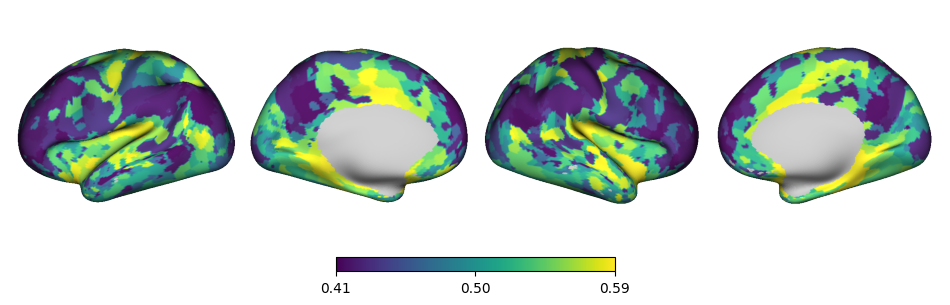

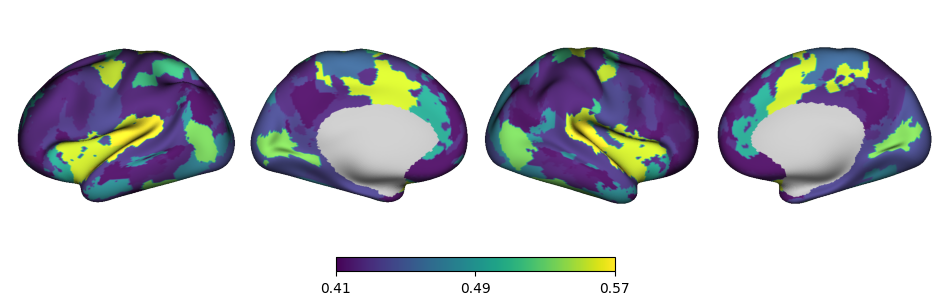

In [466]:
vertex_plot(mean_parcel_fc_nz[pni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 95))
# vertex_plot(mean_intraparcel_fc_nz[pni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))
vertex_plot(mean_network_fc_nz[vni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))

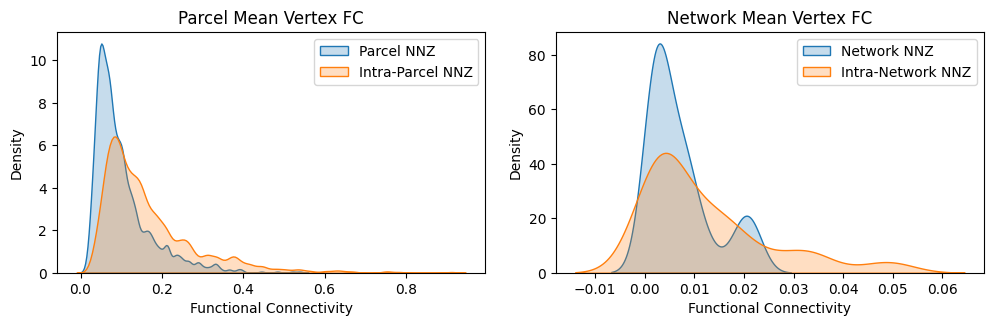

In [458]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.tight_layout(w_pad=2)

for ax, label, (roi_means, intraroi_means) in zip(axes, ["Parcel", "Network"], [[mean_parcel_fc_nz, mean_intraparcel_fc_nz],
                                                   [mean_network_fc_nz, mean_intranetwork_fc_nz]]):

    bw = 0.1 if len(roi_means) > 500 else 0.4
    sns.kdeplot(roi_means, bw_method=bw, ax=ax, label=f"{label} NNZ", fill=True)
    sns.kdeplot(intraroi_means, bw_method=bw, ax=ax, label=f"Intra-{label} NNZ", fill=True)
    ax.set(title=f"{label} Mean Vertex FC", ylabel="Density", xlabel="Functional Connectivity")
    ax.legend()

[Text(0.5, 25.722222222222214, 'Intra Network Mean Vertex Functional Connectivity'),
 Text(619.9949494949494, 0.5, 'Network')]

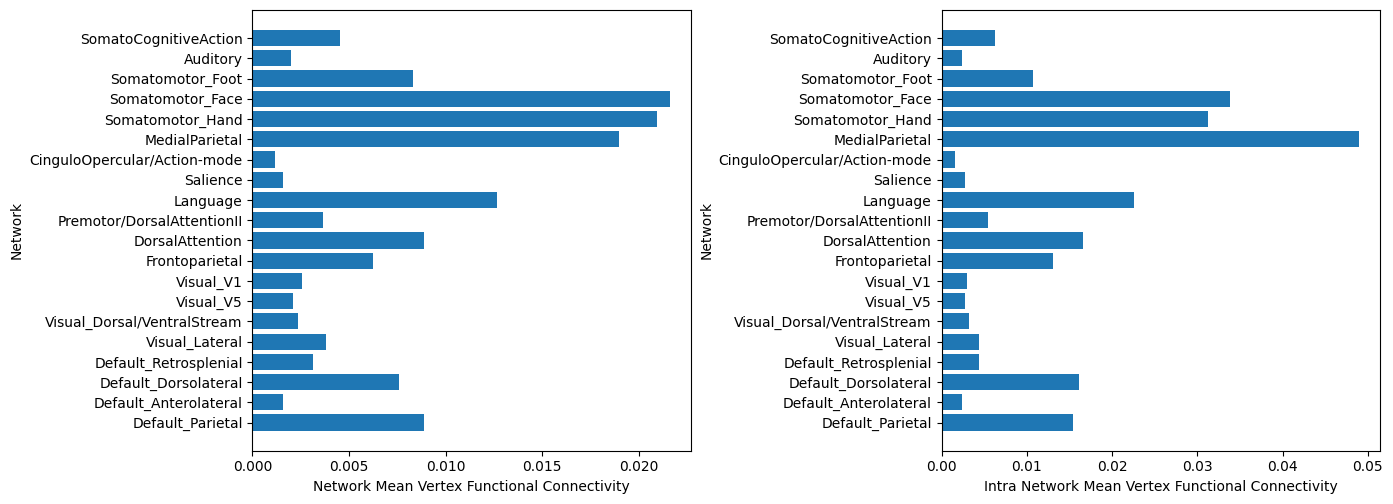

In [459]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
axes[0].barh(network_labels[:-1], mean_network_fc_nz)
axes[0].set(xlabel="Network Mean Vertex Functional Connectivity", ylabel="Network")

axes[1].barh(network_labels[:-1], mean_intranetwork_fc_nz)
axes[1].set(xlabel="Intra Network Mean Vertex Functional Connectivity", ylabel="Network")

<Axes: >

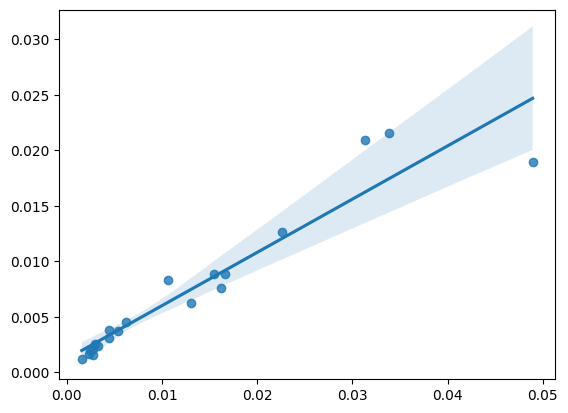

In [460]:
sns.regplot(x=mean_intranetwork_fc_nz, y=mean_network_fc_nz)

In [200]:
vni, vns = np.load(network_save_path)
vni = vni.astype("int")

sc = scipy.sparse.load_npz(voxel_FC_save_path)
cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
sc_cortex = sc[cortex_index][:, cortex_index]

partition = np.load(partition_save_path)
vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
pni = remapped_vertex_labels

cluster_labels = np.sort(np.unique(remapped_vertex_labels))
roi_index_set = remapped_vertex_labels.reshape(-1, 1) == cluster_labels

In [305]:
mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, remapped_vertex_labels, only_nonzero=True)
mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)

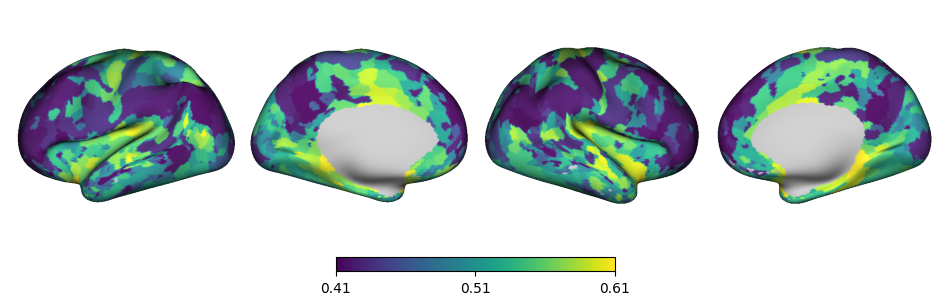

In [343]:
# z = mean_intraparcel_fcs[pni]
z = mean_intraparcel_fc_nz[pni]

# z = mean_parcel_fcs[pni]
z = mean_parcel_fc_nz[pni]

# z = mean_network_fc_s[vni]
# z = mean_network_fc_nz[vni]

# z = mean_intranetwork_fc_s[vni]
# z = mean_intranetwork_fc_nz[vni]

z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))

values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.viridis, ax=ax)

In [171]:
template_cifti = nb.load(cached_dtseries_paths[ex_index])

# full_vertex_data = pm.utils.load_voxel_data(dtseries_paths[ex_index])
# print(full_vertex_data.shape)
# vertex_data = pm.na.get_cortex_data(full_vertex_data, template_cifti)
# vertex_data = None

partition = np.load(parcel_save_paths[ex_index])
vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)

In [172]:
vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]

cluster_labels = np.sort(np.unique(remapped_vertex_labels))
roi_index_set = remapped_vertex_labels.reshape(-1, 1) == cluster_labels

FC, spatial, network_labels = pm.na.load_priors()
sp_corr = pm.utils.np_corr(spatial.T, roi_index_set * 1)

# roi_mean_signals = np.array([vertex_data[:, ri].mean(axis=1) for ri in roi_index_set.T]).T
# roi_mean_FCs = pm.utils.np_corr(vertex_data, roi_mean_signals)
# fc_corr = pm.utils.np_corr(FC.T, roi_mean_FCs)
# sp_fc_corr = sp_corr * fc_corr

sp_fc_index = np.argmax(sp_corr, axis=0)
# sp_fc_index = np.argmax(sp_fc_corr, axis=0)

vn = sp_fc_index[remapped_vertex_labels]
pn = remapped_vertex_labels
# roi_mean_signals = np.array([vertex_data[:, ri].mean(axis=1) for ri in roi_index_set.T]).T
# roi_mean_FCs = utils.np_corr(vertex_data, roi_mean_signals)

In [173]:
pn.shape

(59412,)

In [174]:
sc = scipy.sparse.load_npz(voxel_FC_save_paths[ex_index])

cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
sc_cortex = sc[cortex_index][:, cortex_index]

In [175]:
sc, roi_index_set.shape

(<Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 8332312 stored elements and shape (91282, 91282)>,
 (59412, 1071))

In [176]:
parcel_fc_nz = [np.nanmean(sc_cortex[roi_index_set[:, i]].data) for i in range(roi_index_set.shape[1])]

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_58350/3375776889.py:1: RuntimeWarning: Mean of empty slice
  parcel_fc_nz = [np.nanmean(sc_cortex[roi_index_set[:, i]].data) for i in range(roi_index_set.shape[1])]


In [177]:
parcel_fc_s = np.vstack([np.mean(sc_cortex[roi_index_set[:, i]], axis=0).reshape(-1) for i in range(roi_index_set.shape[1])])
mean_parcel_fcs = np.array([np.mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_s])
mean_intraparcel_fcs = np.array([np.mean(parcel_fc[(parcel_fc > 0) & (pn == i)]) for i, parcel_fc in enumerate(parcel_fc_s)])

mean_intranetwork_parcel_fcs = np.array([np.mean(parcel_fc[(parcel_fc > 0) & (vn == sp_fc_index[i])]) for i, parcel_fc in enumerate(parcel_fc_s)])

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/matrixlib/defmatrix.py:448: RuntimeWarning: Mean of empty slice.
  return N.ndarray.mean(self, axis, dtype, out, keepdims=True)._collapse(axis)
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [178]:
np.nanmean(mean_intraparcel_fcs), np.nanmean(mean_intranetwork_parcel_fcs), np.nanmean(mean_parcel_fcs), len(sp_fc_index)

(np.float32(0.16633612), np.float32(0.12497975), np.float32(0.10196546), 1071)

In [179]:
nnz_row = np.array(np.sum(sc_cortex > 0, axis=0))

vertex_fc_s = np.array(sc_cortex.sum(axis=0)) / (nnz_row + (nnz_row == 0))

In [180]:
z = mean_intranetwork_parcel_fcs[vn]
z = mean_intraparcel_fcs[pn]
# z = mean_parcel_fcs[pn]
z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))

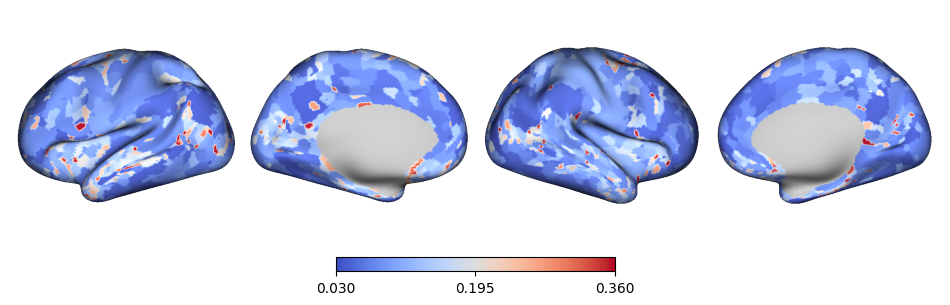

In [181]:
values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

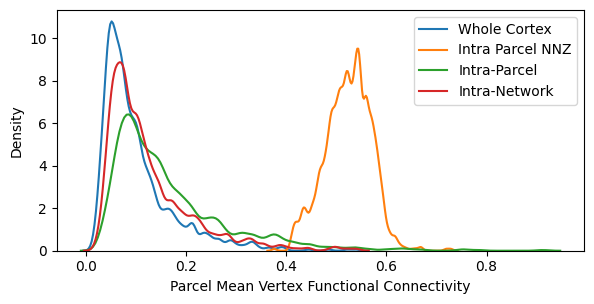

In [182]:
bw = 0.1
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
fig.tight_layout(w_pad=0)
sns.kdeplot(mean_parcel_fcs, bw_method=bw, ax=ax, label="Whole Cortex")
sns.kdeplot(parcel_fc_nz, bw_method=bw, ax=ax, label="Intra Parcel NNZ")
sns.kdeplot(mean_intraparcel_fcs, bw_method=bw, ax=ax, label="Intra-Parcel")
sns.kdeplot(mean_intranetwork_parcel_fcs, bw_method=bw, ax=ax, label="Intra-Network")
ax.set(xlabel="Parcel Mean Vertex Functional Connectivity", ylabel="Density")
ax.legend()

In [107]:
network_fc_s = np.array([np.mean(sc_cortex[vn == i], axis=0) for i in range(np.max(vn) + 1)]).squeeze()
mean_network_fc_s = np.array([np.mean(network_fc[network_fc > 0]) for network_fc in network_fc_s])

mean_intranetwork_fc_s = np.array([np.mean(network_fc[(network_fc > 0) & (vn == i)]) for i, network_fc in enumerate(network_fc_s)])

In [115]:
mean_network_fc_s.shape

(20,)

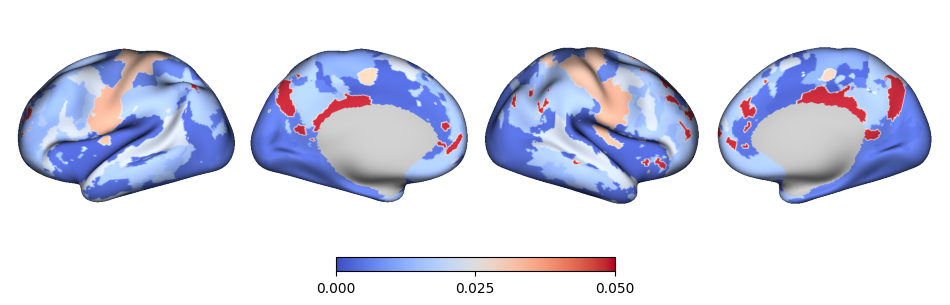

In [119]:
z = mean_network_fc_s[vn]
z = mean_intranetwork_fc_s[vn]

z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))
values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

[Text(0.5, 25.722222222222214, 'Intra Network Mean Vertex Functional Connectivity'),
 Text(619.9949494949494, 0.5, 'Network')]

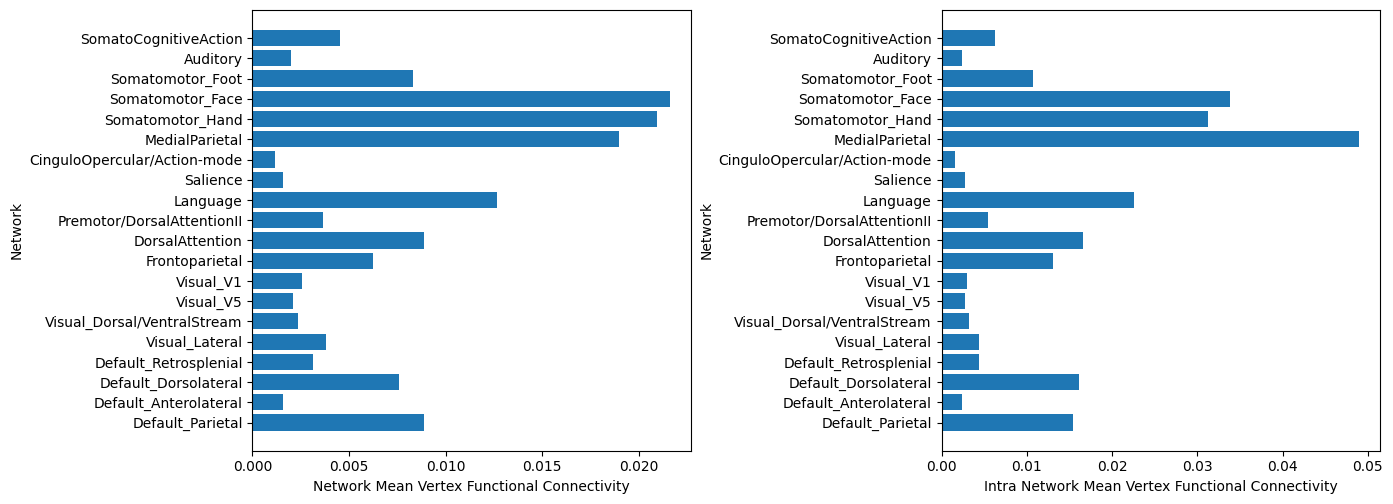

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
axes[0].barh(network_labels[:-1], mean_network_fc_s)
axes[0].set(xlabel="Network Mean Vertex Functional Connectivity", ylabel="Network")

axes[1].barh(network_labels[:-1], mean_intranetwork_fc_s)
axes[1].set(xlabel="Intra Network Mean Vertex Functional Connectivity", ylabel="Network")